In [ ]:
import math
from typing import TypedDict

from IPython.display import Image
from langgraph.graph import StateGraph


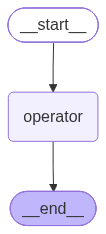

In [12]:
class AgentState(TypedDict):
    nums: list[int]
    operator: str
    name: str
    result: str


def operator_node(state: AgentState) -> AgentState:
    if state["operator"] == "*":
        result = math.prod(state["nums"])
    elif state["operator"] == "+":
        result = sum(state["nums"])
    else:
        state["result"] = (
            f"Invalid operator, only '+' and '*' are supported. {state['operator']} was provided"
        )
        return state

    state["result"] = f"Hello {state['name']}, your result is {result}"
    return state


graph = StateGraph(AgentState)

graph.add_node("operator", operator_node)
graph.set_entry_point("operator")
graph.set_finish_point("operator")

app = graph.compile()
app

In [15]:
result = app.invoke(AgentState(nums=[1, 2, 3, 4], name="Zeyad", operator="-", result=""))
result['result']

"Invalid operator, only '+' and '*' are supported. - was provided"